# Projet M07 — AT&T Spam Detector

**Contexte** : AT&T souhaite automatiser la détection des SMS indésirables (spam) pour protéger ses utilisateurs. Ce notebook présente une solution de classification binaire (spam / ham) basée sur le contenu textuel des messages, dans le cadre du module M07 Deep Learning.

## 1. Objectifs et livrables

- **Objectif** : Construire un détecteur de spam qui classe automatiquement les SMS à partir de leur contenu.
- **Livrables** : Préprocessing reproductible, entraînement d’un ou plusieurs modèles de deep learning, rapport clair des performances (train / validation / test).
- **Cadre** : alignement avec les objectifs du module (qualité de la préparation des données, choix du réseau, généralisation, critères d’évaluation).

## 2. Imports et configuration

In [ ]:
import re
import string
import random
from collections import Counter
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)
import matplotlib.pyplot as plt

RANDOM_SEED = 42


def set_seed(seed: int) -> None:
    """Fixer les graines pour reproductibilité."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: cuda


## 3. Chargement et exploration des données

In [2]:
URL_DATASET = (
    "https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/"
    "Deep+Learning/project/spam.csv"
)

df = pd.read_csv(URL_DATASET, encoding="latin-1", on_bad_lines="skip")

# Colonnes typiques: v1 (spam/ham), v2 (message)
if "v1" not in df.columns and len(df.columns) >= 2:
    df.columns = ["v1", "v2"] + list(df.columns[2:])

df.head(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


Dimensions: (5572, 5)

Colonnes: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Répartition des classes (v1):
v1
ham     4825
spam     747
Name: count, dtype: int64

Valeurs manquantes:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Doublons: 403


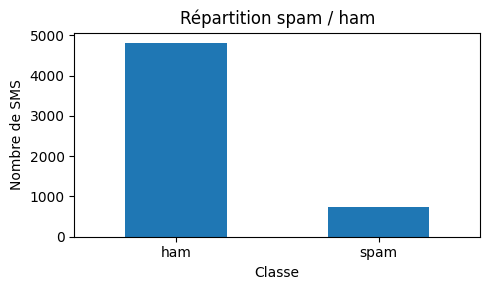

In [3]:
print("Dimensions:", df.shape)
print("\nColonnes:", df.columns.tolist())
print("\nRépartition des classes (v1):")
print(df["v1"].value_counts())
print("\nValeurs manquantes:")
print(df.isna().sum())
print("\nDoublons:", df.duplicated().sum())

counts = df["v1"].value_counts()
counts.plot(kind="bar", figsize=(5, 3), title="Répartition spam / ham")
plt.xlabel("Classe")
plt.ylabel("Nombre de SMS")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Statistiques par classe (spam vs ham) :


length                n_words            
            mean median  max       mean median  max
v1                                                 
ham    71.023627   52.0  910  14.200622   11.0  171
spam  138.866131  149.0  224  23.851406   25.0   35

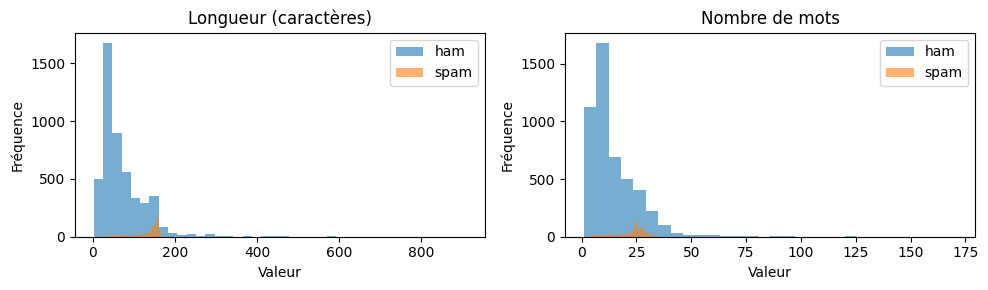

,length,n_words
count,5572.000000,5572.000000
mean,80.118808,15.494436
std,59.690841,11.329427
min,2.000000,1.000000
25%,36.000000,7.000000
50%,61.000000,12.000000
75%,121.000000,23.000000
max,910.000000,171.000000


In [4]:
text_col = "v2" if "v2" in df.columns else df.columns[1]
df["length"] = df[text_col].astype(str).str.len()
df["n_words"] = df[text_col].astype(str).str.split().str.len()

print("Statistiques par classe (spam vs ham) :")
display(df.groupby("v1")[["length", "n_words"]].agg(["mean", "median", "max"]))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for cls, grp in df.groupby("v1"):
    axes[0].hist(grp["length"], bins=40, alpha=0.6, label=cls)
    axes[1].hist(grp["n_words"], bins=30, alpha=0.6, label=cls)
axes[0].set_title("Longueur (caractères)")
axes[1].set_title("Nombre de mots")
for ax in axes:
    ax.legend()
    ax.set_xlabel("Valeur")
    ax.set_ylabel("Fréquence")
plt.tight_layout()
plt.show()

df[["length", "n_words"]].describe()

## 4. Préparation des données

### 4.1 Nettoyage et encodage des labels

Les données sont du texte non structuré (SMS). On nettoie le texte et on encode les labels pour obtenir des signaux exploitables par un réseau de neurones.

In [5]:
def clean_text(text: str) -> str:
    """Nettoyage basique : minuscules, suppression ponctuation excessive."""
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    text = re.sub(r"[%s]" % re.escape(string.punctuation), " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


df["text_clean"] = df[text_col].apply(clean_text)
df["label"] = (df["v1"] == "spam").astype(int)

df = df[df["text_clean"].str.len() > 0].copy()
df.drop_duplicates(subset=["text_clean", "label"], inplace=True)

print("Après nettoyage:", df.shape)
print(df[["v1", "label", "text_clean"]].head())

Après nettoyage: (5127, 9)
     v1  label                                         text_clean
0   ham      0  go until jurong point crazy available only in ...
1   ham      0                            ok lar joking wif u oni
2  spam      1  free entry in 2 a wkly comp to win fa cup fina...
3   ham      0        u dun say so early hor u c already then say
4   ham      0  nah i don t think he goes to usf he lives arou...


### 4.2 Split initial sur le texte nettoyé

Le split est effectué **avant** la construction du vocabulaire et l’augmentation pour éviter toute fuite d’information (*data leakage*). Le vocabulaire et les transformations ne doivent tenir compte que du jeu d’entraînement.

In [6]:
texts_raw = df["text_clean"].tolist()
labels_raw = df["label"].values.astype(np.int64)

X_temp_raw, X_test_raw, y_temp, y_test = train_test_split(
    texts_raw,
    labels_raw,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=labels_raw,
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=y_temp,
)

print(f"Train : {len(X_train_raw)} | Val : {len(X_val_raw)} | Test : {len(X_test_raw)}")
print("Répartition train  :", np.bincount(y_train), " (0=ham, 1=spam)")
print("Répartition val    :", np.bincount(y_val))
print("Répartition test   :", np.bincount(y_test))

Train : 3703 | Val : 654 | Test : 770
Répartition train  : [3248  455]  (0=ham, 1=spam)
Répartition val    : [574  80]
Répartition test   : [675  95]


### 4.3 Construction du vocabulaire (sur le train uniquement)

Le vocabulaire est construit **exclusivement sur le train set** pour éviter tout leakage. Les mots présents dans le val ou le test mais absents du train sont mappés sur le token spécial `<unk>`.

In [7]:
PAD_IDX = 0
UNK_IDX = 1


def build_vocab(texts: list, min_freq: int = 2) -> dict:
    """Construit un vocabulaire mot -> indice à partir d'une liste de textes."""
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    vocab = {"<pad>": PAD_IDX, "<unk>": UNK_IDX}
    idx = len(vocab)
    for w, c in counter.items():
        if c >= min_freq:
            vocab[w] = idx
            idx += 1
    return vocab


def text_to_ids(text: str, vocab: dict, max_len: int) -> list:
    """Convertit un texte en liste d'indices (padding à max_len)."""
    tokens = text.split()[:max_len]
    ids = [vocab.get(w, UNK_IDX) for w in tokens]
    ids = ids + [PAD_IDX] * (max_len - len(ids))
    return ids


vocab = build_vocab(X_train_raw)
vocab_size = len(vocab)
MAX_LEN = 80

seq_lens_train = [len(t.split()) for t in X_train_raw]
print(f"Vocabulaire construit sur le train : {vocab_size} tokens")
print(f"Longueur moyenne des SMS (train)   : {np.mean(seq_lens_train):.1f} mots")
print(f"Longueur max                       : {max(seq_lens_train)} mots")
print(f"MAX_LEN retenu                     : {MAX_LEN}")

Vocabulaire construit sur le train : 3105 tokens
Longueur moyenne des SMS (train)   : 15.6 mots
Longueur max                       : 119 mots
MAX_LEN retenu                     : 80


### 4.4 Augmentation de données (sur le train uniquement)

L'augmentation est appliquée **uniquement sur le jeu d'entraînement**, après le split, pour ne pas contaminer l'évaluation sur val/test. Technique : **échange aléatoire de deux mots** (*random swap*), simple et sans bibliothèque externe.

In [8]:
def augment_random_swap(text: str) -> str:
    """Échange deux mots aléatoires dans la phrase (augmentation par permutation locale)."""
    words = text.split()
    if len(words) < 3:
        return text
    i, j = random.sample(range(len(words)), 2)
    words[i], words[j] = words[j], words[i]
    return " ".join(words)


def augment_dataset(texts: list, labels_arr: np.ndarray, frac: float = 0.3) -> tuple:
    """
    Enrichit le jeu d'entraînement en ajoutant des exemples augmentés (random swap).

    Args:
        texts: liste de textes nettoyés (train only).
        labels_arr: tableau numpy des labels correspondants.
        frac: fraction des exemples à dupliquer avec augmentation.

    Returns:
        tuple (texts_augmented, labels_augmented)
    """
    n = int(len(texts) * frac)
    indices = random.sample(range(len(texts)), n)
    extra_texts = [augment_random_swap(texts[i]) for i in indices]
    extra_labels = labels_arr[indices]
    return texts + extra_texts, np.concatenate([labels_arr, extra_labels])


X_train_aug, y_train_aug = augment_dataset(X_train_raw, y_train, frac=0.3)
print(f"Train avant augmentation : {len(X_train_raw)} exemples")
print(f"Train après augmentation : {len(X_train_aug)} exemples (+{len(X_train_aug) - len(X_train_raw)})")
print("Répartition train augmenté :", np.bincount(y_train_aug), " (0=ham, 1=spam)")

Train avant augmentation : 3703 exemples
Train après augmentation : 4813 exemples (+1110)
Répartition train augmenté : [4239  574]  (0=ham, 1=spam)


### 4.5 Tokenisation → tenseurs et DataLoaders

On convertit maintenant les textes en séquences d’indices via `text_to_ids`, puis on crée les `Dataset` PyTorch et les `DataLoader` pour chaque split.

In [9]:
X_train_seq = [text_to_ids(t, vocab, MAX_LEN) for t in X_train_aug]
X_val_seq   = [text_to_ids(t, vocab, MAX_LEN) for t in X_val_raw]
X_test_seq  = [text_to_ids(t, vocab, MAX_LEN) for t in X_test_raw]


class SpamDataset(Dataset):
    """Dataset PyTorch pour séquences tokenisées et labels binaires."""

    def __init__(self, sequences: list, labels):
        self.data   = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels,    dtype=torch.long)

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int):
        return self.data[idx], self.labels[idx]


train_dataset = SpamDataset(X_train_seq, y_train_aug)
val_dataset   = SpamDataset(X_val_seq,   y_val)
test_dataset  = SpamDataset(X_test_seq,  y_test)

BATCH_SIZE   = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

sample_x, sample_y = next(iter(train_loader))
print(f"Forme d’un batch — textes : {sample_x.shape}, labels : {sample_y.shape}")


Forme d’un batch — textes : torch.Size([32, 80]), labels : torch.Size([32])


## 5. Choix du modèle et de l’architecture

**Types de réseaux** :
- **Classiques (MLP)** : conviennent pour des représentations fixes (ex. embedding moyen).
- **Convolutifs (CNN)** : peuvent traiter des n-grammes sur des séquences (texte) mais sont surtout utilisés en vision.
- **Récursifs (RNN/LSTM)** : adaptés aux séquences (ordre des mots) ; plus coûteux.

**Choix** : Pour des SMS courts et un volume de données limité, un **réseau à embedding + pooling** (comme en D07) est pertinent : il convertit le texte en tenseurs via l’embedding, puis résume la séquence par pooling (moyenne) et prédit avec des couches fully connected. C’est un bon compromis simplicité / efficacité. Une alternative serait un LSTM ou du transfer learning (BERT, D08) pour de meilleures performances au prix de la complexité.

## 6. Architecture du modèle

In [10]:
class SpamClassifier(nn.Module):
    """
    Classifieur binaire (spam/ham) par embedding + pooling + couches denses.
    """

    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int = 64, num_classes: int = 2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(x)
        pooled = self.pooling(embedded.permute(0, 2, 1)).squeeze(-1)
        out = self.fc1(pooled)
        out = self.relu(out)
        out = self.dropout(out)
        return self.fc2(out)


embed_dim = 64
hidden_dim = 64
model = SpamClassifier(vocab_size=vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim)
model = model.to(device)
print(model)

SpamClassifier(
  (embedding): Embedding(3105, 64, padding_idx=0)
  (pooling): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)


## 7. Fonction de coût et optimiseur

**Classification binaire** : on utilise **Cross Entropy** (sortie logits sur 2 classes), adaptée à la classification supervisée. BCELoss avec sigmoïde serait équivalent pour 2 classes ; CrossEntropyLoss est standard en PyTorch pour la classification multi-classes et binaire.

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 15

## 8. Boucle d’entraînement et validation

In [12]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(targets.cpu().numpy())
    n = len(loader)
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / n, acc


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits = model(inputs)
            loss = criterion(logits, targets)
            total_loss += loss.item()
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(targets.cpu().numpy())
    n = len(loader)
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / n, acc


history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

Epoch [1/15] Loss: 0.4574, Acc: 0.8290 | Val Loss: 0.2851, Val Acc: 0.8777
Epoch [2/15] Loss: 0.1811, Acc: 0.9316 | Val Loss: 0.1108, Val Acc: 0.9755
Epoch [3/15] Loss: 0.0809, Acc: 0.9790 | Val Loss: 0.0741, Val Acc: 0.9817
Epoch [4/15] Loss: 0.0550, Acc: 0.9857 | Val Loss: 0.0631, Val Acc: 0.9862
Epoch [5/15] Loss: 0.0430, Acc: 0.9882 | Val Loss: 0.0579, Val Acc: 0.9908
Epoch [6/15] Loss: 0.0327, Acc: 0.9911 | Val Loss: 0.0561, Val Acc: 0.9878
Epoch [7/15] Loss: 0.0246, Acc: 0.9936 | Val Loss: 0.0554, Val Acc: 0.9878
Epoch [8/15] Loss: 0.0204, Acc: 0.9944 | Val Loss: 0.0526, Val Acc: 0.9893
Epoch [9/15] Loss: 0.0158, Acc: 0.9956 | Val Loss: 0.0519, Val Acc: 0.9878
Epoch [10/15] Loss: 0.0141, Acc: 0.9961 | Val Loss: 0.0574, Val Acc: 0.9878
Epoch [11/15] Loss: 0.0116, Acc: 0.9967 | Val Loss: 0.0564, Val Acc: 0.9878
Epoch [12/15] Loss: 0.0099, Acc: 0.9977 | Val Loss: 0.0552, Val Acc: 0.9862
Epoch [13/15] Loss: 0.0084, Acc: 0.9977 | Val Loss: 0.0570, Val Acc: 0.9878
Epoch [14/15] Loss: 0

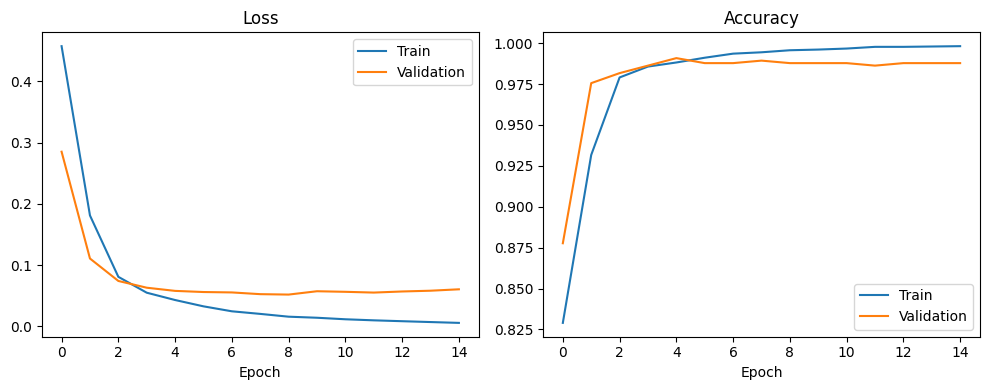

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history["loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].set_xlabel("Epoch")
axes[1].plot(history["accuracy"], label="Train")
axes[1].plot(history["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.show()

## 9. Évaluation sur l’ensemble de test

La généralisation est vérifiée sur des données jamais vues (test set).

In [14]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        logits = model(inputs)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(targets.numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="binary")
test_precision = precision_score(all_labels, all_preds, average="binary", zero_division=0)
test_recall = recall_score(all_labels, all_preds, average="binary", zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

print("=== Métriques sur l'ensemble de test ===")
print(f"Accuracy:  {test_acc:.4f}")
print(f"F1:        {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print("\nMatrice de confusion (ligne=réel, colonne=prédit):")
print(cm)

=== Métriques sur l'ensemble de test ===
Accuracy:  0.9779
F1:        0.9071
Precision: 0.9432
Recall:    0.8737

Matrice de confusion (ligne=réel, colonne=prédit):
[[670   5]
 [ 12  83]]


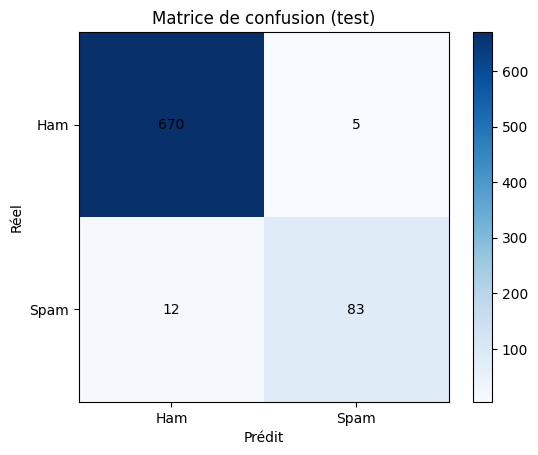

In [15]:
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.title("Matrice de confusion (test)")
plt.show()

## 10. Conclusion et performance

- **Performance atteinte** : Les métriques sur l’ensemble de **test** (accuracy, F1, précision, rappel) sont reportées ci-dessus. Le modèle montre une capacité de généralisation dès lors que la loss et l’accuracy de validation suivent celles d’entraînement sans sur-apprentissage marqué.
- **Limites** : Vocabulaire limité au corpus ; messages très courts ou jargon non vu peuvent dégrader les performances.
- **Pistes d’amélioration** : Transfer learning (BERT / modèle pré-entraîné, D08), LSTM pour mieux capturer l’ordre des mots, plus de données ou augmentation plus riche.

## 11. Annexes — Exemples de prédictions

In [ ]:
def predict_single(model, text: str, vocab: dict, max_len: int, device) -> int:
    model.eval()
    ids = text_to_ids(clean_text(text), vocab, max_len)
    x = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(x)
    return logits.argmax(dim=1).item()


samples = [
    "Free entry in 2 a wkly comp to win FA Cup final",
    "Hello, can we meet tomorrow at 5pm?",
]
for s in samples:
    pred = predict_single(model, s, vocab, MAX_LEN, device)
    print(f"'{s[:50]}...' -> {'Spam' if pred == 1 else 'Ham'}")

'Free entry in 2 a wkly comp to win FA Cup final...' -> Spam
'Hello, can we meet tomorrow at 5pm?...' -> Ham
